In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data" / "PADS"

print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATA_DIR)
print("Dataset found:", DATA_DIR.exists())

Project directory: C:\Users\Michi\OneDrive\Desktop\CSCI543_PADS_Project
Dataset directory: C:\Users\Michi\OneDrive\Desktop\CSCI543_PADS_Project\data\PADS
Dataset found: True


In [7]:
for item in DATA_DIR.iterdir():
    print(item.name)

LICENSE.txt
movement
patients
preprocessed
questionnaire
scripts
SHA256SUMS.txt


In [9]:
PATIENT_DIR = DATA_DIR / "patients"

patient_files = list(PATIENT_DIR.iterdir())

print("Number of files:", len(patient_files))
print("\nFirst 10 files:")

for f in patient_files[:10]:
    print(f.name)

Number of files: 469

First 10 files:
patient_001.json
patient_002.json
patient_003.json
patient_004.json
patient_005.json
patient_006.json
patient_007.json
patient_008.json
patient_009.json
patient_010.json


In [11]:
MOVEMENT_DIR = DATA_DIR / "movement"

movement_items = list(MOVEMENT_DIR.iterdir())

print("Number of items:", len(movement_items))
print("\nFirst 10:")

for f in movement_items[:10]:
    print(f.name)

Number of items: 470

First 10:
observation_001.json
observation_002.json
observation_003.json
observation_004.json
observation_005.json
observation_006.json
observation_007.json
observation_008.json
observation_009.json
observation_010.json


In [13]:
# Inspect one patient file

sample_patient_path = PATIENT_DIR / "patient_001.json"

with open(sample_patient_path, "r") as f:
    sample_patient = json.load(f)

print("Patient JSON keys:")
print(sample_patient.keys())

print("\nFull patient record:")
print(json.dumps(sample_patient, indent=2))

Patient JSON keys:
dict_keys(['resource_type', 'id', 'study_id', 'condition', 'disease_comment', 'age_at_diagnosis', 'age', 'height', 'weight', 'gender', 'handedness', 'appearance_in_kinship', 'appearance_in_first_grade_kinship', 'effect_of_alcohol_on_tremor'])

Full patient record:
{
  "resource_type": "patient",
  "id": "001",
  "study_id": "PADS",
  "condition": "Healthy",
  "disease_comment": "-",
  "age_at_diagnosis": 56,
  "age": 56,
  "height": 173,
  "weight": 78,
  "gender": "male",
  "handedness": "right",
  "appearance_in_kinship": true,
  "appearance_in_first_grade_kinship": true,
  "effect_of_alcohol_on_tremor": "Unknown"
}


In [15]:
# Inspect one movement observation file

sample_movement_path = MOVEMENT_DIR / "observation_001.json"

with open(sample_movement_path, "r") as f:
    sample_movement = json.load(f)

print("Movement JSON keys:")
print(sample_movement.keys())

print("\nTop-level structure:")
print(json.dumps(sample_movement, indent=2)[:5000])

Movement JSON keys:
dict_keys(['resource_type', 'subject_id', 'study_id', 'device_id', 'id', 'endianness', 'sampling_rate', 'data_type', 'bits', 'session'])

Top-level structure:
{
  "resource_type": "observation",
  "subject_id": "001",
  "study_id": "PADS",
  "device_id": "Apple Watch Series 4",
  "id": "Neurological Assessment",
  "endianness": "little",
  "sampling_rate": 100,
  "data_type": "float",
  "bits": 32,
  "session": [
    {
      "record_name": "Relaxed",
      "rows": 2048,
      "records": [
        {
          "device_location": "LeftWrist",
          "channels": [
            "Time",
            "Accelerometer_X",
            "Accelerometer_Y",
            "Accelerometer_Z",
            "Gyroscope_X",
            "Gyroscope_Y",
            "Gyroscope_Z"
          ],
          "units": [
            "s",
            "g",
            "g",
            "g",
            "rad/s",
            "rad/s",
            "rad/s"
          ],
          "file_name": "timeseries/001_R

In [17]:
# Check what the extra item in the movement folder is

movement_json_files = list(MOVEMENT_DIR.glob("*.json"))

print("Total items in movement folder:", len(movement_items))
print("JSON files:", len(movement_json_files))

non_json_items = [
    item.name for item in movement_items
    if item.suffix.lower() != ".json"
]

print("\nNon-JSON items:")
print(non_json_items)

Total items in movement folder: 470
JSON files: 469

Non-JSON items:
['timeseries']


In [19]:
# Load all patient metadata into one dataframe

patient_records = []

for file_path in sorted(PATIENT_DIR.glob("patient_*.json")):
    with open(file_path, "r") as f:
        patient_records.append(json.load(f))

patients_df = pd.DataFrame(patient_records)

print("Shape:", patients_df.shape)
patients_df.head()

Shape: (469, 14)


,resource_type,id,study_id,condition,disease_comment,age_at_diagnosis,age,height,weight,gender,handedness,appearance_in_kinship,appearance_in_first_grade_kinship,effect_of_alcohol_on_tremor
0,patient,001,PADS,Healthy,-,56,56,173,78,male,right,True,True,Unknown
1,patient,002,PADS,Other Movement Disorders,Left-Sided resting tremor and hypokinesia with...,69,81,193,104,male,right,False,None,No effect
2,patient,003,PADS,Healthy,-,45,45,170,78,female,right,False,None,Unknown
3,patient,004,PADS,Parkinson's,IPS akinetic-rigid type,63,67,161,90,female,right,False,None,No effect
4,patient,005,PADS,Parkinson's,IPS tremordominant type,65,75,172,86,male,left,False,None,Unknown


In [21]:
# Diagnosis / condition distribution

condition_counts = patients_df["condition"].value_counts(dropna=False)

print(condition_counts)

condition
Parkinson's                 276
Healthy                      79
Other Movement Disorders     60
Essential Tremor             28
Atypical Parkinsonism        15
Multiple Sclerosis           11
Name: count, dtype: int64


In [23]:
# Basic participant characteristics

display(
    patients_df[
        ["id", "condition", "age", "gender", "handedness", "height", "weight"]
    ].head(10)
)

,id,condition,age,gender,handedness,height,weight
0,001,Healthy,56,male,right,173,78
1,002,Other Movement Disorders,81,male,right,193,104
2,003,Healthy,45,female,right,170,78
3,004,Parkinson's,67,female,right,161,90
4,005,Parkinson's,75,male,left,172,86
5,006,Parkinson's,72,female,right,171,115
6,007,Other Movement Disorders,74,male,right,181,94
7,008,Parkinson's,73,female,right,168,65
8,009,Parkinson's,47,male,left,184,85
9,010,Parkinson's,56,male,right,187,77


In [27]:
print("Number of participants:", patients_df["id"].nunique())
print("\nGender:")
print(patients_df["gender"].value_counts(dropna=False))

print("\nHandedness:")
print(patients_df["handedness"].value_counts(dropna=False))

print("\nAge summary:")
display(patients_df["age"].describe())

Number of participants: 469

Gender:
gender
male      281
female    188
Name: count, dtype: int64

Handedness:
handedness
right    437
left      32
Name: count, dtype: int64

Age summary:


count    469.000000
mean      64.240938
std       10.698847
min       40.000000
25%       56.000000
50%       65.000000
75%       72.000000
max       90.000000
Name: age, dtype: float64

In [30]:
# Build a table describing all movement sessions

session_records = []

for file_path in sorted(MOVEMENT_DIR.glob("observation_*.json")):
    with open(file_path, "r") as f:
        observation = json.load(f)

    subject_id = observation["subject_id"]

    for session in observation["session"]:
        session_records.append({
            "subject_id": subject_id,
            "record_name": session["record_name"],
            "rows": session["rows"],
            "n_wrist_records": len(session["records"])
        })

sessions_df = pd.DataFrame(session_records)

print("Total session records:", len(sessions_df))
print("Unique participants:", sessions_df["subject_id"].nunique())
print("Unique movement tasks:", sessions_df["record_name"].nunique())

sessions_df.head()

Total session records: 5159
Unique participants: 469
Unique movement tasks: 11


,subject_id,record_name,rows,n_wrist_records
0,001,Relaxed,2048,2
1,001,RelaxedTask,2048,2
2,001,StretchHold,1024,2
3,001,LiftHold,1024,2
4,001,HoldWeight,1024,2


In [32]:
# How many participants completed each task?

task_summary = (
    sessions_df
    .groupby("record_name")
    .agg(
        n_participants=("subject_id", "nunique"),
        median_rows=("rows", "median"),
        min_rows=("rows", "min"),
        max_rows=("rows", "max")
    )
    .sort_values("n_participants", ascending=False)
)

display(task_summary)

,n_participants,median_rows,min_rows,max_rows
record_name,,,,
CrossArms,469,1024.0,1024,1024
DrinkGlas,469,1024.0,1024,1024
Entrainment,469,2048.0,2048,2048
HoldWeight,469,1024.0,1024,1024
LiftHold,469,1024.0,1024,1024
PointFinger,469,1024.0,1024,1024
Relaxed,469,2048.0,2048,2048
RelaxedTask,469,2048.0,2048,2048
StretchHold,469,1024.0,1024,1024


In [34]:
# Locate one real smartwatch timeseries file

with open(MOVEMENT_DIR / "observation_001.json", "r") as f:
    obs_001 = json.load(f)

sample_session = obs_001["session"][0]
sample_record = sample_session["records"][0]

print("Task:", sample_session["record_name"])
print("Wrist:", sample_record["device_location"])
print("Channels:", sample_record["channels"])
print("Units:", sample_record["units"])
print("File:", sample_record["file_name"])

signal_path = MOVEMENT_DIR / sample_record["file_name"]

print("\nFull path:")
print(signal_path)

print("\nFile exists:", signal_path.exists())

Task: Relaxed
Wrist: LeftWrist
Channels: ['Time', 'Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z', 'Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z']
Units: ['s', 'g', 'g', 'g', 'rad/s', 'rad/s', 'rad/s']
File: timeseries/001_Relaxed_LeftWrist.txt

Full path:
C:\Users\Michi\OneDrive\Desktop\CSCI543_PADS_Project\data\PADS\movement\timeseries\001_Relaxed_LeftWrist.txt

File exists: True


In [36]:
with open(signal_path, "r") as f:
    for _ in range(5):
        print(f.readline().strip())

0.0000000000,-0.0039583882,0.0023599046,0.0017461196,-0.0154924262,0.0056162034,0.0010342058
0.0099029541,-0.0040048202,0.0022586959,0.0008355394,-0.0122763924,0.0056047519,-0.0032175307
0.0199010372,0.0008331696,0.0022254365,0.0009437218,-0.0090513043,0.0024323943,-0.0021368200
0.0299069881,-0.0001905998,0.0041091219,0.0000004783,-0.0089108236,0.0021535615,-0.0009305412
0.0399839878,0.0017689625,0.0040636435,-0.0019023999,-0.0078295805,0.0000339518,0.0001445769


In [38]:
# Load the sample smartwatch signal

signal_df = pd.read_csv(
    signal_path,
    header=None,
    names=sample_record["channels"]
)

print("Shape:", signal_df.shape)
display(signal_df.head())

Shape: (2048, 7)


,Time,Accelerometer_X,Accelerometer_Y,Accelerometer_Z,Gyroscope_X,Gyroscope_Y,Gyroscope_Z
0,0.000000,-0.003958,0.002360,1.746120e-03,-0.015492,0.005616,0.001034
1,0.009903,-0.004005,0.002259,8.355394e-04,-0.012276,0.005605,-0.003218
2,0.019901,0.000833,0.002225,9.437218e-04,-0.009051,0.002432,-0.002137
3,0.029907,-0.000191,0.004109,4.783000e-07,-0.008911,0.002154,-0.000931
4,0.039984,0.001769,0.004064,-1.902400e-03,-0.007830,0.000034,0.000145


In [40]:
# Verify timing and sampling rate

duration = signal_df["Time"].iloc[-1] - signal_df["Time"].iloc[0]

median_dt = signal_df["Time"].diff().median()
estimated_sampling_rate = 1 / median_dt

print(f"Recording duration: {duration:.2f} seconds")
print(f"Median sampling interval: {median_dt:.4f} seconds")
print(f"Estimated sampling rate: {estimated_sampling_rate:.2f} Hz")

Recording duration: 20.46 seconds
Median sampling interval: 0.0100 seconds
Estimated sampling rate: 100.05 Hz


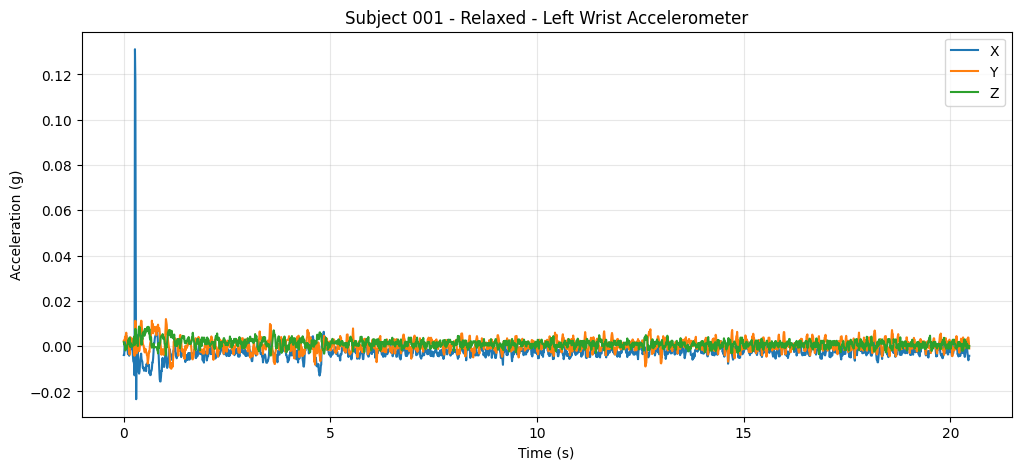

In [42]:
# Plot accelerometer signals

plt.figure(figsize=(12, 5))

plt.plot(signal_df["Time"], signal_df["Accelerometer_X"], label="X")
plt.plot(signal_df["Time"], signal_df["Accelerometer_Y"], label="Y")
plt.plot(signal_df["Time"], signal_df["Accelerometer_Z"], label="Z")

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.title("Subject 001 - Relaxed - Left Wrist Accelerometer")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

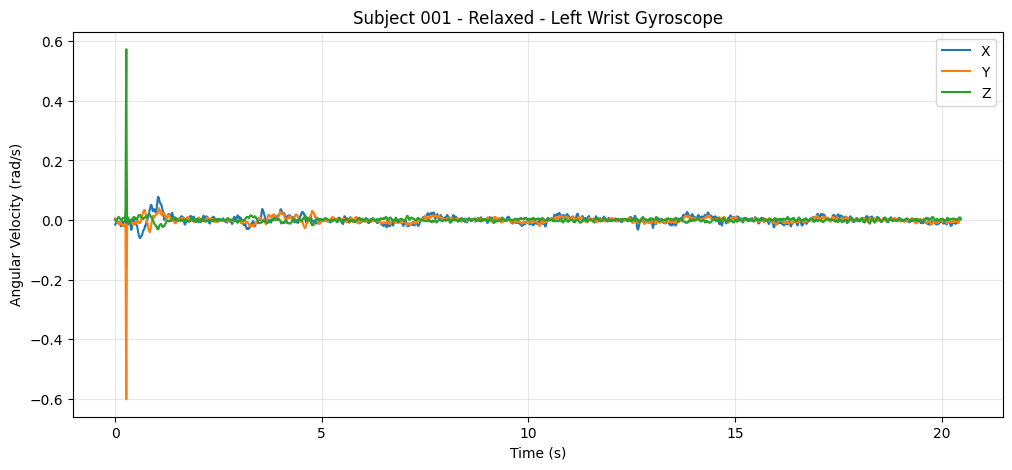

In [54]:
# Plot gyroscope signals

plt.figure(figsize=(12, 5))

plt.plot(signal_df["Time"], signal_df["Gyroscope_X"], label="X")
plt.plot(signal_df["Time"], signal_df["Gyroscope_Y"], label="Y")
plt.plot(signal_df["Time"], signal_df["Gyroscope_Z"], label="Z")

plt.xlabel("Time (s)")
plt.ylabel("Angular Velocity (rad/s)")
plt.title("Subject 001 - Relaxed - Left Wrist Gyroscope")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [46]:
patients_df["condition"].value_counts(dropna=False)

condition
Parkinson's                 276
Healthy                      79
Other Movement Disorders     60
Essential Tremor             28
Atypical Parkinsonism        15
Multiple Sclerosis           11
Name: count, dtype: int64

In [48]:
condition_counts = patients_df["condition"].value_counts(dropna=False)

print("Condition distribution:")
print(condition_counts)

Condition distribution:
condition
Parkinson's                 276
Healthy                      79
Other Movement Disorders     60
Essential Tremor             28
Atypical Parkinsonism        15
Multiple Sclerosis           11
Name: count, dtype: int64


In [50]:
# Check for missing demographic information

columns_to_check = [
    "condition",
    "age",
    "gender",
    "handedness",
    "height",
    "weight"
]

print("Missing values:")
print(patients_df[columns_to_check].isna().sum())

Missing values:
condition     0
age           0
gender        0
handedness    0
height        0
weight        0
dtype: int64


In [52]:
# Confirm subject IDs match between patient and movement metadata

patient_ids = set(patients_df["id"].astype(str).str.zfill(3))
movement_ids = set(sessions_df["subject_id"].astype(str).str.zfill(3))

print("Patients without movement data:", patient_ids - movement_ids)
print("Movement data without patient metadata:", movement_ids - patient_ids)

Patients without movement data: set()
Movement data without patient metadata: set()


In [56]:
# Create primary binary-classification cohort:
# Parkinson's disease vs Healthy controls

binary_cohort = patients_df[
    patients_df["condition"].isin(["Parkinson's", "Healthy"])
].copy()

binary_cohort["target"] = binary_cohort["condition"].map({
    "Healthy": 0,
    "Parkinson's": 1
})

print("Primary analysis cohort")
print("-----------------------")
print("Total participants:", len(binary_cohort))
print()
print(binary_cohort["condition"].value_counts())

print("\nPercentages:")
print(
    binary_cohort["condition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

Primary analysis cohort
-----------------------
Total participants: 355

condition
Parkinson's    276
Healthy         79
Name: count, dtype: int64

Percentages:
condition
Parkinson's    77.7
Healthy        22.3
Name: proportion, dtype: float64


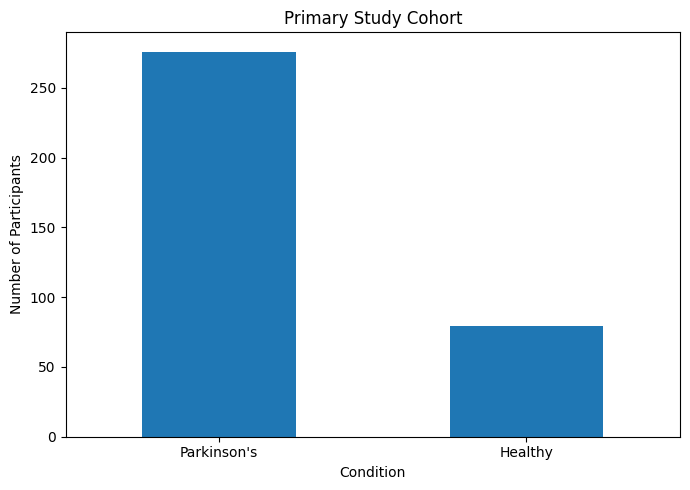

In [58]:
# Plot class distribution

class_counts = binary_cohort["condition"].value_counts()

plt.figure(figsize=(7, 5))
class_counts.plot(kind="bar")

plt.title("Primary Study Cohort")
plt.xlabel("Condition")
plt.ylabel("Number of Participants")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [60]:
# Demographic summary by diagnostic group

demographic_summary = (
    binary_cohort
    .groupby("condition")
    .agg(
        n=("id", "count"),
        mean_age=("age", "mean"),
        std_age=("age", "std"),
        mean_height=("height", "mean"),
        mean_weight=("weight", "mean")
    )
)

display(demographic_summary.round(2))

,n,mean_age,std_age,mean_height,mean_weight
condition,,,,,
Healthy,79,62.95,12.45,170.48,78.75
Parkinson's,276,65.36,9.64,175.71,83.78


In [64]:
# Gender distribution by group

gender_table = pd.crosstab(
    binary_cohort["condition"],
    binary_cohort["gender"]
)

display(gender_table)

gender,female,male
condition,,
Healthy,50,29
Parkinson's,81,195


In [66]:
def load_pads_signal(subject_id, task, wrist="LeftWrist"):
    """
    Load one PADS smartwatch recording.

    Parameters
    ----------
    subject_id : str or int
        Participant identifier, e.g. 1 or '001'
    task : str
        Movement task, e.g. 'TouchNose'
    wrist : str
        'LeftWrist' or 'RightWrist'

    Returns
    -------
    signal_df : pandas.DataFrame
        Time, accelerometer, and gyroscope signals
    metadata : dict
        Information about the recording
    """

    subject_id = str(subject_id).zfill(3)

    observation_path = (
        MOVEMENT_DIR / f"observation_{subject_id}.json"
    )

    with open(observation_path, "r") as f:
        observation = json.load(f)

    # Find requested task
    matching_sessions = [
        session
        for session in observation["session"]
        if session["record_name"] == task
    ]

    if len(matching_sessions) == 0:
        raise ValueError(
            f"Task '{task}' not found for subject {subject_id}"
        )

    session = matching_sessions[0]

    # Find requested wrist
    matching_records = [
        record
        for record in session["records"]
        if record["device_location"] == wrist
    ]

    if len(matching_records) == 0:
        raise ValueError(
            f"Wrist '{wrist}' not found for subject {subject_id}, task {task}"
        )

    record = matching_records[0]

    signal_path = MOVEMENT_DIR / record["file_name"]

    signal_df = pd.read_csv(
        signal_path,
        header=None,
        names=record["channels"]
    )

    metadata = {
        "subject_id": subject_id,
        "task": task,
        "wrist": wrist,
        "sampling_rate": observation["sampling_rate"],
        "expected_rows": session["rows"],
        "actual_rows": len(signal_df),
        "file_name": record["file_name"]
    }

    return signal_df, metadata

In [68]:
touch_nose_df, touch_nose_meta = load_pads_signal(
    subject_id="001",
    task="TouchNose",
    wrist="LeftWrist"
)

print(touch_nose_meta)
display(touch_nose_df.head())

{'subject_id': '001', 'task': 'TouchNose', 'wrist': 'LeftWrist', 'sampling_rate': 100, 'expected_rows': 1024, 'actual_rows': 1024, 'file_name': 'timeseries/001_TouchNose_LeftWrist.txt'}


,Time,Accelerometer_X,Accelerometer_Y,Accelerometer_Z,Gyroscope_X,Gyroscope_Y,Gyroscope_Z
0,0.000000,-0.314262,-0.406344,-0.647017,1.169301,0.751087,-0.456878
1,0.009687,-0.187177,-0.592680,-0.430099,0.724863,0.728832,-0.282192
2,0.019858,-0.221640,-0.550364,-0.347897,0.449836,0.680792,-0.276376
3,0.029833,-0.190459,-0.423449,-0.322618,0.499378,0.547535,-0.409425
4,0.039866,-0.193140,-0.320662,-0.314953,0.751616,0.513395,-0.755720


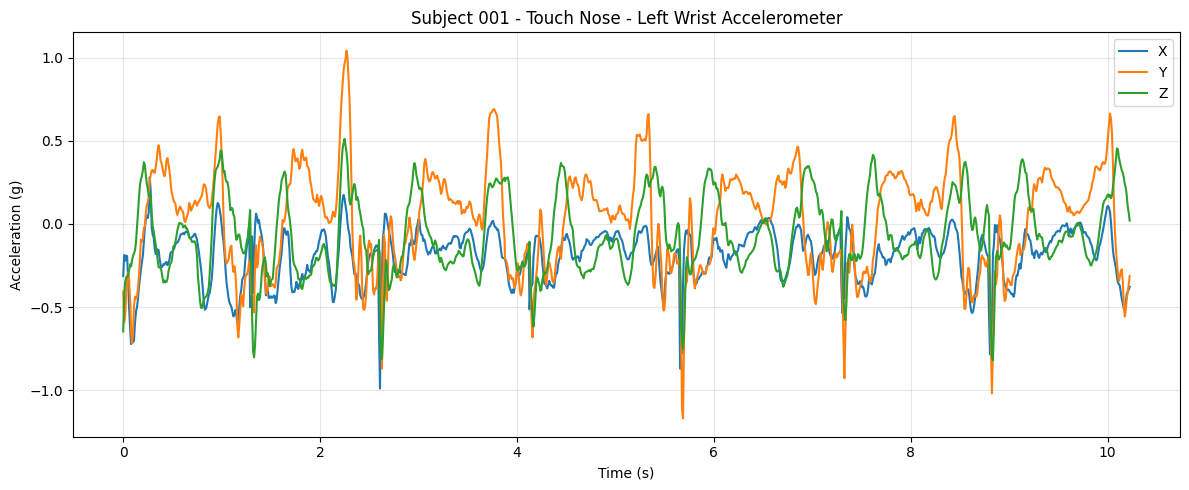

In [70]:
plt.figure(figsize=(12, 5))

plt.plot(
    touch_nose_df["Time"],
    touch_nose_df["Accelerometer_X"],
    label="X"
)
plt.plot(
    touch_nose_df["Time"],
    touch_nose_df["Accelerometer_Y"],
    label="Y"
)
plt.plot(
    touch_nose_df["Time"],
    touch_nose_df["Accelerometer_Z"],
    label="Z"
)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.title("Subject 001 - Touch Nose - Left Wrist Accelerometer")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

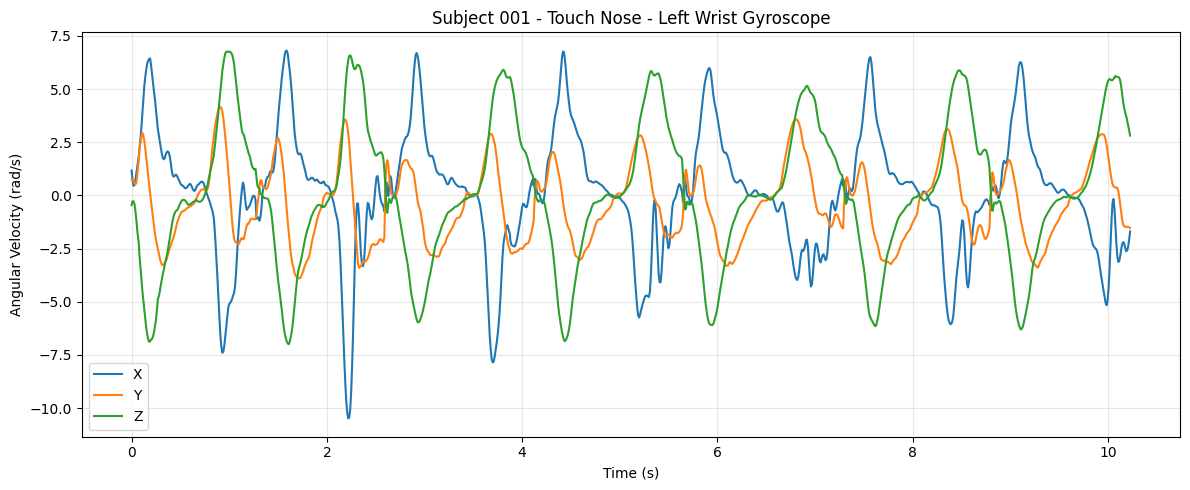

In [72]:
plt.figure(figsize=(12, 5))

plt.plot(
    touch_nose_df["Time"],
    touch_nose_df["Gyroscope_X"],
    label="X"
)
plt.plot(
    touch_nose_df["Time"],
    touch_nose_df["Gyroscope_Y"],
    label="Y"
)
plt.plot(
    touch_nose_df["Time"],
    touch_nose_df["Gyroscope_Z"],
    label="Z"
)

plt.xlabel("Time (s)")
plt.ylabel("Angular Velocity (rad/s)")
plt.title("Subject 001 - Touch Nose - Left Wrist Gyroscope")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [74]:
# Check the sample recording for missing or infinite values

print("Missing values:")
print(touch_nose_df.isna().sum())

print("\nInfinite values:")
print(
    np.isinf(
        touch_nose_df.select_dtypes(include=np.number)
    ).sum()
)

Missing values:
Time               0
Accelerometer_X    0
Accelerometer_Y    0
Accelerometer_Z    0
Gyroscope_X        0
Gyroscope_Y        0
Gyroscope_Z        0
dtype: int64

Infinite values:
Time               0
Accelerometer_X    0
Accelerometer_Y    0
Accelerometer_Z    0
Gyroscope_X        0
Gyroscope_Y        0
Gyroscope_Z        0
dtype: int64


In [76]:
# Find one healthy and one Parkinson's participant

healthy_id = (
    binary_cohort.loc[
        binary_cohort["condition"] == "Healthy", "id"
    ]
    .astype(str)
    .str.zfill(3)
    .iloc[0]
)

pd_id = (
    binary_cohort.loc[
        binary_cohort["condition"] == "Parkinson's", "id"
    ]
    .astype(str)
    .str.zfill(3)
    .iloc[0]
)

print("Healthy example:", healthy_id)
print("Parkinson's example:", pd_id)

Healthy example: 001
Parkinson's example: 004


In [78]:
healthy_signal, _ = load_pads_signal(
    healthy_id,
    "TouchNose",
    "LeftWrist"
)

pd_signal, _ = load_pads_signal(
    pd_id,
    "TouchNose",
    "LeftWrist"
)

In [80]:
def add_signal_magnitudes(df):
    df = df.copy()

    df["Accel_Magnitude"] = np.sqrt(
        df["Accelerometer_X"]**2 +
        df["Accelerometer_Y"]**2 +
        df["Accelerometer_Z"]**2
    )

    df["Gyro_Magnitude"] = np.sqrt(
        df["Gyroscope_X"]**2 +
        df["Gyroscope_Y"]**2 +
        df["Gyroscope_Z"]**2
    )

    return df


healthy_signal = add_signal_magnitudes(healthy_signal)
pd_signal = add_signal_magnitudes(pd_signal)

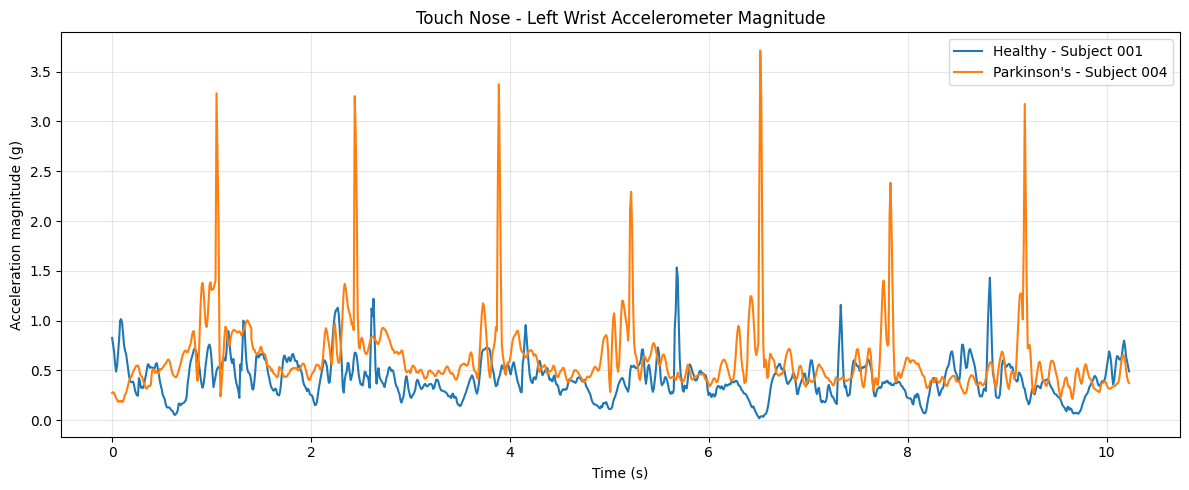

In [82]:
plt.figure(figsize=(12, 5))

plt.plot(
    healthy_signal["Time"],
    healthy_signal["Accel_Magnitude"],
    label=f"Healthy - Subject {healthy_id}"
)

plt.plot(
    pd_signal["Time"],
    pd_signal["Accel_Magnitude"],
    label=f"Parkinson's - Subject {pd_id}"
)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration magnitude (g)")
plt.title("Touch Nose - Left Wrist Accelerometer Magnitude")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

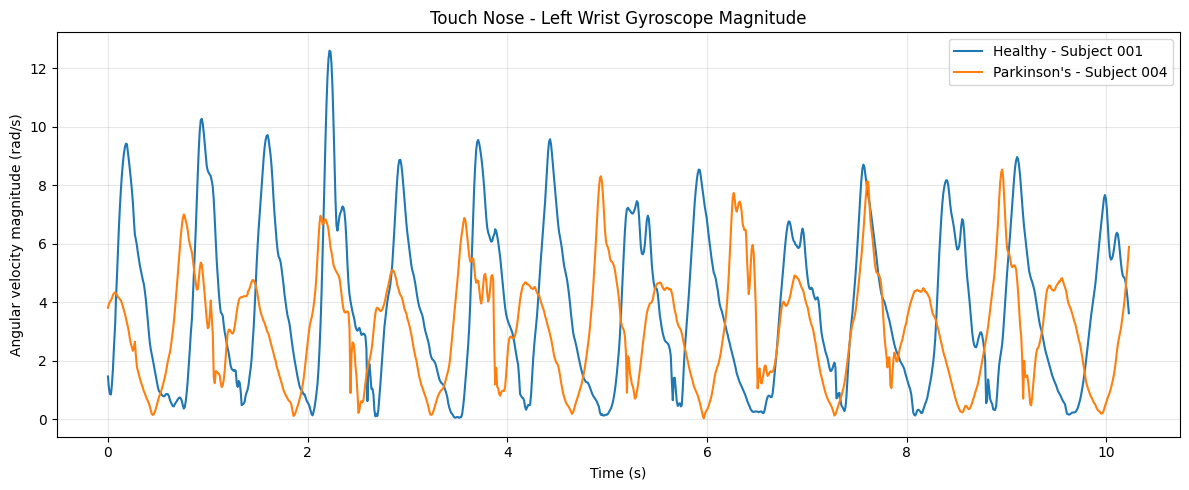

In [84]:
plt.figure(figsize=(12, 5))

plt.plot(
    healthy_signal["Time"],
    healthy_signal["Gyro_Magnitude"],
    label=f"Healthy - Subject {healthy_id}"
)

plt.plot(
    pd_signal["Time"],
    pd_signal["Gyro_Magnitude"],
    label=f"Parkinson's - Subject {pd_id}"
)

plt.xlabel("Time (s)")
plt.ylabel("Angular velocity magnitude (rad/s)")
plt.title("Touch Nose - Left Wrist Gyroscope Magnitude")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()